In [ ]:
import os
import urllib.request
import sys

import numpy as np
import pandas as pd
import random
import joblib

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

urls = {
    "X_train_scaf_rus.npy" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/X_train_scaf_rus.npy",
    "X_test_scaf.npy" : "https://github.com/daniellaeme/ACE-Inhibitor-QSAR/blob/main/data/X_test_scaf.npy?raw=true",
    "y_train_scaf_rus.npy" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/y_train_scaf_rus.npy",
    "y_test_scaf.npy" : "https://github.com/daniellaeme/ACE-Inhibitor-QSAR/blob/main/data/y_test_scaf.npy?raw=true",
    "rus_rf_model.pkl" : "https://github.com/daniellaeme/ACE-Inhibitor-QSAR/blob/main/models/rus_rf_model.pkl?raw=true",
    "rus_xgb_model.pkl" : "https://github.com/daniellaeme/ACE-Inhibitor-QSAR/blob/main/models/rus_xgb_model.pkl?raw=true",
}

for filename, url in urls.items():
    if os.path.exists(filename):
        os.remove(filename)
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded: {filename}")

sys.path.append('.')

print("\nSuccess! All modules imported and ready to go.")

Downloaded: X_train_scaf_rus.npy
Downloaded: X_test_scaf.npy
Downloaded: y_train_scaf_rus.npy
Downloaded: y_test_scaf.npy
Downloaded: rus_rf_model.pkl
Downloaded: rus_xgb_model.pkl

Success! All modules imported and ready to go.


In [ ]:
rus_rf = joblib.load('rus_rf_model.pkl')
rus_xgb = joblib.load('rus_xgb_model.pkl')

X_train_scaf_rus = np.load('X_train_scaf_rus.npy')
X_test_scaf = np.load('X_test_scaf.npy')
y_train_scaf_rus = np.load('y_train_scaf_rus.npy')
y_test_scaf = np.load('y_test_scaf.npy')

# Hyperparameter Tuning

In [ ]:
X_train_scaf_rus

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

In [ ]:
y_train_scaf_rus

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1])

In [ ]:
# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid_search = GridSearchCV(
    estimator=rus_rf,
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=5,                             # For 5-fold cross-validation
    n_jobs=-1,                        # Computer uses all its processors
    verbose=1
)

rf_grid_search.fit(X_train_scaf_rus, y_train_scaf_rus)
rf_tuned = rf_grid_search.best_estimator_

print(f"\nBest Random Forest Parameters: {rf_grid_search.best_params_}")

y_pred_rf_tuned = rf_tuned.predict(X_test_scaf)

print("\nTuned Random Forest Model Evaluation")
print(f"Classification Report:\n", classification_report(y_test_scaf, y_pred_rf_tuned, target_names=['Inactive (0)', 'Active (1)']))
print(f"Confusion Matrix:\n", confusion_matrix(y_test_scaf, y_pred_rf_tuned))

joblib.dump(rf_tuned, 'rf_tuned_model.pkl')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}

Tuned Random Forest Model Evaluation
Classification Report:
               precision    recall  f1-score   support

Inactive (0)       0.72      0.64      0.68        36
  Active (1)       0.82      0.87      0.84        68

    accuracy                           0.79       104
   macro avg       0.77      0.75      0.76       104
weighted avg       0.78      0.79      0.79       104

Confusion Matrix:
 [[23 13]
 [ 9 59]]


['rf_tuned_model.pkl']

Despite tuning and expanding the parameter grid, the Random Forest model's performance plateaued at a Macro F1 score of 0.76. This indicates, this algorithm has reached its learning capacity for this specific scaffold split.


In [ ]:
# XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid_search = GridSearchCV(
    estimator=rus_xgb,
    param_grid=xgb_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_scaf_rus, y_train_scaf_rus)
xgb_tuned = xgb_grid_search.best_estimator_

print(f"\nBest XGBoost Parameters: {xgb_grid_search.best_params_}")

y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaf)

print("\nTuned XGBoost Model Evaluation")
print(f"Classification Report:\n", classification_report(y_test_scaf, y_pred_xgb_tuned, target_names=['Inactive (0)', 'Active (1)']))
print(f"Confusion Matrix:\n", confusion_matrix(y_test_scaf, y_pred_xgb_tuned))

joblib.dump(xgb_tuned, 'xgb_tuned_model.pkl')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Tuned XGBoost Model Evaluation
Classification Report:
               precision    recall  f1-score   support

Inactive (0)       0.76      0.86      0.81        36
  Active (1)       0.92      0.85      0.89        68

    accuracy                           0.86       104
   macro avg       0.84      0.86      0.85       104
weighted avg       0.86      0.86      0.86       104

Confusion Matrix:
 [[31  5]
 [10 58]]


['xgb_tuned_model.pkl']

XGBoost achieved a superior macro F1 score of 0.85. Moving forward, this model wil define the Applicability Domain and serve as the foundation for the Explainable AI (SHAP) Analysis.

# Applicability Domain Visualisation

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_scaf_rus)

X_train_pca = pca.fit_transform(X_train_scaf_rus)
X_test_pca = pca.transform(X_test_scaf)

centroid = np.mean(X_train_pca, axis=0)
distances = np.linalg.norm(X_train_pca - centroid, axis=1)
threshold = np.percentile(distances, 95)

print(f"Centroid: {centroid}")
print(f"Threshold: {threshold}")

Centroid: [-5.38623052e-17  4.50684594e-17]
Threshold: 2.6891432129170396


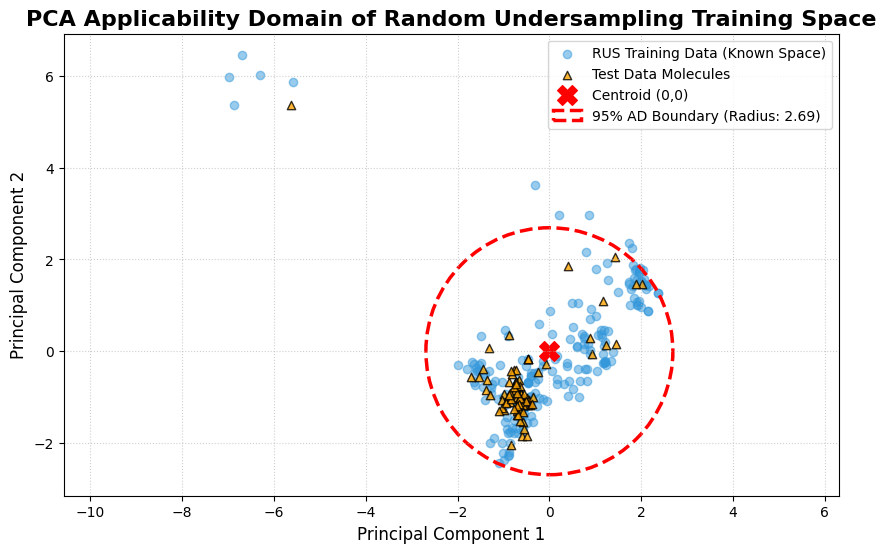

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the training set
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    alpha=0.5, c='#3498db',
    label='RUS Training Data (Known Space)'
)

# Plot the Test set
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    alpha=0.8, color='orange', marker='^', edgecolor='k',
    label='Test Data Molecules'
)

# Plot the Centroid
plt.scatter(
    centroid[0],
    centroid[1],
    color='red', marker='X', s=200,
    label='Centroid (0,0)'
)

# Draw the 95th Percentile Boundary (The AD Fence)
ad_circle = Circle(
    (centroid[0], centroid[1]), threshold, color='red', fill=False,        # passing the center coords and the threshold as the radius
    linestyle='--', linewidth=2.5, label=f'95% AD Boundary (Radius: {threshold:.2f})')

# Add the circle to the plot
plt.gca().add_patch(ad_circle)

plt.title('PCA Applicability Domain of Random Undersampling Training Space', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.axis('equal') # This forces the X and Y axes to scale equally and present as a circle instead of an oval.
plt.savefig('pca_applicability_domain.png', dpi=300, bbox_inches='tight')
plt.show()

# Y-Randomisation

In [ ]:
y_random_scores = []

for i in range(10):
    y_shuffled = np.copy(y_train_scaf_rus)
    np.random.shuffle(y_shuffled)

    dummy_model = RandomForestClassifier(random_state=i)      # Train a fresh model on the real fingerprints but fake labels
    dummy_model.fit(X_train_scaf_rus, y_shuffled)

    y_pred_random = dummy_model.predict(X_test_scaf)
    score = f1_score(y_test_scaf, y_pred_random, average='macro')
    y_random_scores.append(score)

print(f"Average F1 Score after Y-Randomization: {np.mean(y_random_scores):.3f}")

Average F1 Score after Y-Randomization: 0.483


**CONCLUSION**: Because the F1 score dropped from ~0.85 to ~0.50, we prove the model learnt real structural alerts, not noise.